# Top YouTube Creator Stats & Trends — End-to-End CRISP-DM Case Study

**Professional Google Colab / Master's-Level Data Science Notebook**

This notebook implements a complete, reproducible CRISP-DM workflow for the Kaggle-style **Top YouTube Creator Stats & Trends** dataset, covering:

- Business understanding and analytical objectives
- Raw data understanding and quality auditing
- Data cleaning and entity resolution
- Numeric parsing (`K/M/B` suffixes)
- Missing-data analysis
- Univariate and multivariate EDA
- Visualization and distribution diagnostics
- Outlier, anomaly, and influence analysis
- Feature engineering and feature selection
- Multicollinearity and PCA diagnostics
- K-Means creator segmentation with stability checks
- Synthetic revenue-target design and leakage audit
- Dummy, Linear, Ridge, Lasso, ElasticNet, Decision Tree, Random Forest, and Gradient Boosting regression
- Cross-validation, MAE, RMSE, $R^2$, held-out test evaluation, residual diagnostics, and ablation analysis
- Final recommendations and deployment-readiness assessment

> **Important scientific limitation:** the supplied CSV contains **no observed creator income/revenue target**. The supervised-learning section therefore uses an explicitly **synthetic fixed-RPM advertising-revenue proxy** for teaching purposes. It must **not** be interpreted as actual creator income.

### CRISP-DM roadmap

1. Business Understanding  
2. Data Understanding  
3. Data Preparation  
4. Modeling  
5. Evaluation  
6. Deployment Assessment

## 0. Notebook usage

Run the notebook top-to-bottom. If the CSV is not already present, the data-loading cell will prompt you to upload it in Google Colab.

Expected filename: `top_youtuber_stats(1).csv` (other CSV filenames also work when uploaded interactively).

In [1]:
# Core imports and reproducibility settings
from pathlib import Path
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

from scipy.stats import kruskal
from sklearn.base import clone
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.decomposition import PCA
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import IsolationForest, RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    silhouette_score, adjusted_rand_score
)
from sklearn.model_selection import train_test_split, StratifiedKFold, ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, RobustScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeRegressor

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

SEED = 42
np.random.seed(SEED)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("Ready.")

Ready.


In [2]:
# Portable data loading: local runtime first; Colab upload if needed.
candidates = [
    Path("top_youtuber_stats(1).csv"),
    Path("top_youtuber_stats.csv"),
    Path("/content/top_youtuber_stats(1).csv"),
    Path("/content/top_youtuber_stats.csv"),
    Path("/mnt/data/top_youtuber_stats(1).csv"),
]

DATA_PATH = next((p for p in candidates if p.exists()), None)

if DATA_PATH is None:
    try:
        from google.colab import files
        uploaded = files.upload()
        if not uploaded:
            raise FileNotFoundError("No file uploaded.")
        DATA_PATH = Path(next(iter(uploaded.keys())))
    except Exception as exc:
        raise FileNotFoundError(
            "CSV not found. Upload the YouTube creator CSV and rerun this cell."
        ) from exc

print("Using:", DATA_PATH)
df_raw = pd.read_csv(DATA_PATH)
print("Raw shape:", df_raw.shape)
display(df_raw.head())

Using: top_youtuber_stats(1).csv
Raw shape: (1046, 9)


,Rank,Channel Name,Category,Subscribers,Country,Average Views,Average Likes,Average Comments,Content Type
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0000,T-Series,Music & Dance,258.4M,India,135.2K,5.6K,223,NaN
2,2.0000,MrBeast,Video games,236.1M,United States,104M,4M,74K,Humor
3,3.0000,Cocomelon - Nursery Rhymes,Education,171.4M,NaN,5.1M,57.1K,0,NaN
4,4.0000,SET India,NaN,167.1M,India,27.9K,996,7,NaN


# 1. Business Understanding

### Business / analytical objectives

The dataset supports three broad analytical objectives:

1. **Descriptive:** characterize the distribution of subscribers, views, likes, comments, categories, countries, and content types among top creators.
2. **Segmentation:** identify natural creator groups based on audience scale and current engagement.
3. **Supervised modeling:** demonstrate regression methodology for a revenue-like target while explicitly addressing the absence of observed income and avoiding target leakage.

### Unit of analysis

The intended analytical unit is **one YouTube channel**, not one video or one ranking row.

### Key scientific constraint

No column in the raw CSV represents observed income, revenue, RPM, CPM, monetized views, or creator profit. A valid production income model therefore requires external target data.

# 2. Data Understanding — Raw Audit

In [3]:
print("Shape:", df_raw.shape)
print("\nColumns:")
print(df_raw.columns.tolist())
print("\nDtypes:")
display(df_raw.dtypes.to_frame("dtype"))

quality_raw = pd.DataFrame({
    "non_null": df_raw.notna().sum(),
    "missing": df_raw.isna().sum(),
    "missing_pct": df_raw.isna().mean() * 100,
    "n_unique": df_raw.nunique(dropna=True),
})
display(quality_raw)

print("Completely blank rows:", df_raw.isna().all(axis=1).sum())
print("Exact duplicate rows:", df_raw.duplicated().sum())

Shape: (1046, 9)

Columns:
['Rank', 'Channel Name', 'Category', 'Subscribers', 'Country', 'Average Views', 'Average Likes', 'Average Comments', 'Content Type']

Dtypes:


,dtype
Rank,float64
Channel Name,object
Category,object
Subscribers,object
Country,object
Average Views,object
Average Likes,object
Average Comments,object
Content Type,object


,non_null,missing,missing_pct,n_unique
Rank,1045,1,0.0956,1000
Channel Name,1045,1,0.0956,994
Category,695,351,33.5564,23
Subscribers,1045,1,0.0956,287
Country,853,193,18.4512,30
Average Views,1045,1,0.0956,716
Average Likes,1045,1,0.0956,632
Average Comments,1045,1,0.0956,385
Content Type,335,711,67.9732,10


Completely blank rows: 1
Exact duplicate rows: 45


In [4]:
# Inspect rank structure before cleaning.
raw_rank = pd.to_numeric(df_raw["Rank"], errors="coerce")
print("Non-null ranks:", raw_rank.notna().sum())
print("Unique ranks:", raw_rank.nunique())
print("Min / max rank:", raw_rank.min(), raw_rank.max())

# Duplicate channel-name report among populated records.
populated = df_raw.loc[~df_raw.isna().all(axis=1)].copy()
dup_names = populated[populated.duplicated("Channel Name", keep=False)].sort_values(["Channel Name", "Rank"])
print("Rows participating in repeated Channel Name values:", len(dup_names))
display(dup_names)

Non-null ranks: 1045
Unique ranks: 1000
Min / max rank: 1.0 1000.0
Rows participating in repeated Channel Name values: 102


,Rank,Channel Name,Category,Subscribers,Country,Average Views,Average Likes,Average Comments,Content Type
958,958.0000,#Refúgio Mental,Movies,12.8M,Brazil,266.4K,4.7K,96,Animation
1003,958.0000,#Refúgio Mental,Movies,12.8M,Brazil,266.4K,4.7K,96,Animation
962,962.0000,Avril Lavigne,Music & Dance,12.8M,United States,43K,6.8K,220,NaN
1007,962.0000,Avril Lavigne,Music & Dance,12.8M,United States,43K,6.8K,220,NaN
996,996.0000,BBC Earth,NaN,12.5M,United States,80.3K,1.7K,79,NaN
...,...,...,...,...,...,...,...,...,...
1012,967.0000,vlogger varun,NaN,12.7M,India,3.4M,186.8K,243,NaN
977,977.0000,Теремок - Песенки для детей,NaN,12.6M,Russia,63.3K,106,0,NaN
1022,977.0000,Теремок - Песенки для детей,NaN,12.6M,Russia,63.3K,106,0,NaN
970,970.0000,माशा एंड द बेयर,Animation,12.6M,NaN,165.9K,1.7K,0,Toys


### Raw-audit interpretation

The file contains three distinct structural issues:

- one completely blank row;
- 45 exact repeated rows appended after the intended Top-1000 table;
- six repeated creator entities within the Top-1000 ranking itself.

The repeated entities require **entity resolution**, not merely `drop_duplicates()`, because some repeated channels contain slightly different metric snapshots.

# 3. Data Preparation — Cleaning & Entity Resolution

In [5]:
# Step 1: remove completely empty records.
df_rank = df_raw.loc[~df_raw.isna().all(axis=1)].copy()

# Step 2: remove exact duplicate rows.
df_rank = df_rank.drop_duplicates().copy()

df_rank["Rank"] = pd.to_numeric(df_rank["Rank"], errors="raise").astype(int)
df_rank = df_rank.sort_values("Rank").reset_index(drop=True)

# Validate intended rank table.
assert len(df_rank) == 1000
assert df_rank["Rank"].nunique() == 1000
assert set(df_rank["Rank"]) == set(range(1, 1001))

print("Validated rank-level shape:", df_rank.shape)

Validated rank-level shape: (1000, 9)


In [6]:
# Investigate repeated channel entities in the 1,000-rank table.
entity_dups = df_rank[df_rank.duplicated("Channel Name", keep=False)].sort_values(["Channel Name", "Rank"])
print("Repeated unique channel names:", entity_dups["Channel Name"].nunique())
display(entity_dups)

# Entity-level analytical table: keep the first / highest-ranked occurrence.
# This preserves the original rank value and avoids fabricating averages across unexplained snapshots.
df_creator = (
    df_rank.sort_values("Rank")
           .drop_duplicates("Channel Name", keep="first")
           .reset_index(drop=True)
           .copy()
)

assert len(df_creator) == 994
assert df_creator["Channel Name"].nunique() == 994
print("Creator-level analytical shape:", df_creator.shape)

Repeated unique channel names: 6


,Rank,Channel Name,Category,Subscribers,Country,Average Views,Average Likes,Average Comments,Content Type
742,743,BigTasty,NaN,14.6M,United States,39.8K,1.9K,5,NaN
753,754,BigTasty,NaN,14.5M,United States,40.2K,1.9K,5,NaN
348,349,DeGoBooM,Movies,21.2M,Mexico,208.6K,4.4K,336,Animation
350,351,DeGoBooM,Movies,21.2M,Mexico,208.6K,4.4K,336,Animation
99,100,Jingle Toons,NaN,36.9M,India,62.9K,306,1,NaN
103,104,Jingle Toons,NaN,36.8M,India,49.4K,255,1,NaN
349,350,Linkin Park,Music & Dance,21.1M,United States,31K,3.8K,210,NaN
351,352,Linkin Park,Music & Dance,21.1M,United States,31K,3.8K,210,NaN
749,750,Rosanna Pansino,DIY & Life Hacks,14.6M,United States,44K,2.9K,27,NaN
750,751,Rosanna Pansino,DIY & Life Hacks,14.6M,United States,44K,2.9K,27,NaN


Creator-level analytical shape: (994, 9)


## 3.1 Parse compact numeric magnitudes

In [7]:
MULTIPLIERS = {"": 1, "K": 1_000, "M": 1_000_000, "B": 1_000_000_000}
MAG_PATTERN = re.compile(r"^\s*([+-]?(?:\d+(?:\.\d*)?|\.\d+))\s*([KMBkmb]?)\s*$")

def parse_magnitude(value):
    """Convert strings like 135.2K, 5.1M, 996 to numeric magnitudes."""
    if pd.isna(value):
        return np.nan
    text = str(value).replace(",", "").strip()
    match = MAG_PATTERN.fullmatch(text)
    if match is None:
        return np.nan
    number = float(match.group(1))
    suffix = match.group(2).upper()
    return number * MULTIPLIERS[suffix]

numeric_cols = ["Subscribers", "Average Views", "Average Likes", "Average Comments"]

parse_report = []
for col in numeric_cols:
    original_nonnull = df_creator[col].notna().sum()
    parsed = df_creator[col].map(parse_magnitude)
    parse_failures = original_nonnull - parsed.notna().sum()
    parse_report.append((col, original_nonnull, parse_failures))
    df_creator[col] = parsed

parse_report = pd.DataFrame(parse_report, columns=["column", "original_nonnull", "parse_failures"])
display(parse_report)
assert parse_report["parse_failures"].sum() == 0

,column,original_nonnull,parse_failures
0,Subscribers,994,0
1,Average Views,994,0
2,Average Likes,994,0
3,Average Comments,994,0


In [8]:
# Core integrity checks.
assert (df_creator[numeric_cols] >= 0).all().all()
assert (df_creator["Average Likes"] <= df_creator["Average Views"]).all()
assert (df_creator["Average Comments"] <= df_creator["Average Views"]).all()

quality_clean = pd.DataFrame({
    "missing": df_creator.isna().sum(),
    "missing_pct": df_creator.isna().mean() * 100,
    "n_unique": df_creator.nunique(dropna=True),
})
display(quality_clean)

print("Creator-level rows:", len(df_creator))
print("Zero views:", (df_creator["Average Views"] == 0).sum())
print("Zero likes:", (df_creator["Average Likes"] == 0).sum())
print("Zero comments:", (df_creator["Average Comments"] == 0).sum())

,missing,missing_pct,n_unique
Rank,0,0.0000,994
Channel Name,0,0.0000,994
Category,333,33.5010,23
Subscribers,0,0.0000,287
Country,183,18.4105,30
Average Views,0,0.0000,714
Average Likes,0,0.0000,631
Average Comments,0,0.0000,385
Content Type,672,67.6056,10


Creator-level rows: 994
Zero views: 19
Zero likes: 52
Zero comments: 187


# 4. Exploratory Data Analysis — Univariate

In [9]:
# Rich descriptive statistics.
summary = df_creator[numeric_cols].describe(
    percentiles=[.01, .05, .25, .50, .75, .90, .95, .99]
).T
summary["skew"] = df_creator[numeric_cols].skew()
summary["excess_kurtosis"] = df_creator[numeric_cols].kurt()
summary["zero_pct"] = df_creator[numeric_cols].eq(0).mean() * 100
summary["cv"] = df_creator[numeric_cols].std() / df_creator[numeric_cols].mean()
display(summary)

,count,mean,std,min,1%,5%,25%,50%,75%,90%,95%,99%,max,skew,excess_kurtosis,zero_pct,cv
Subscribers,994.0000,"22,918,812.8773","17,744,596.1648","12,500,000.0000","12,600,000.0000","12,800,000.0000","14,600,000.0000","17,700,000.0000","24,575,000.0000","36,900,000.0000","46,370,000.0000","94,350,000.0000","258,400,000.0000",6.4689,63.9283,0.0000,0.7742
Average Views,994.0000,"1,022,010.5548","3,963,043.6559",0.0000,0.0000,"4,330.0000","35,950.0000","184,250.0000","877,475.0000","2,600,000.0000","4,470,000.0000","10,128,000.0000","104,000,000.0000",19.3560,474.3779,1.9115,3.8777
Average Likes,994.0000,"44,475.1006","166,599.0090",0.0000,0.0000,0.0000,527.2500,"3,800.0000","28,450.0000","113,680.0000","210,555.0000","451,571.0000","4,000,000.0000",15.2897,330.2471,5.2314,3.7459
Average Comments,994.0000,"1,329.8461","9,252.0382",0.0000,0.0000,0.0000,3.0000,62.0000,379.5000,"1,770.0000","4,300.0000","21,070.0000","235,000.0000",18.9924,436.1713,18.8129,6.9572


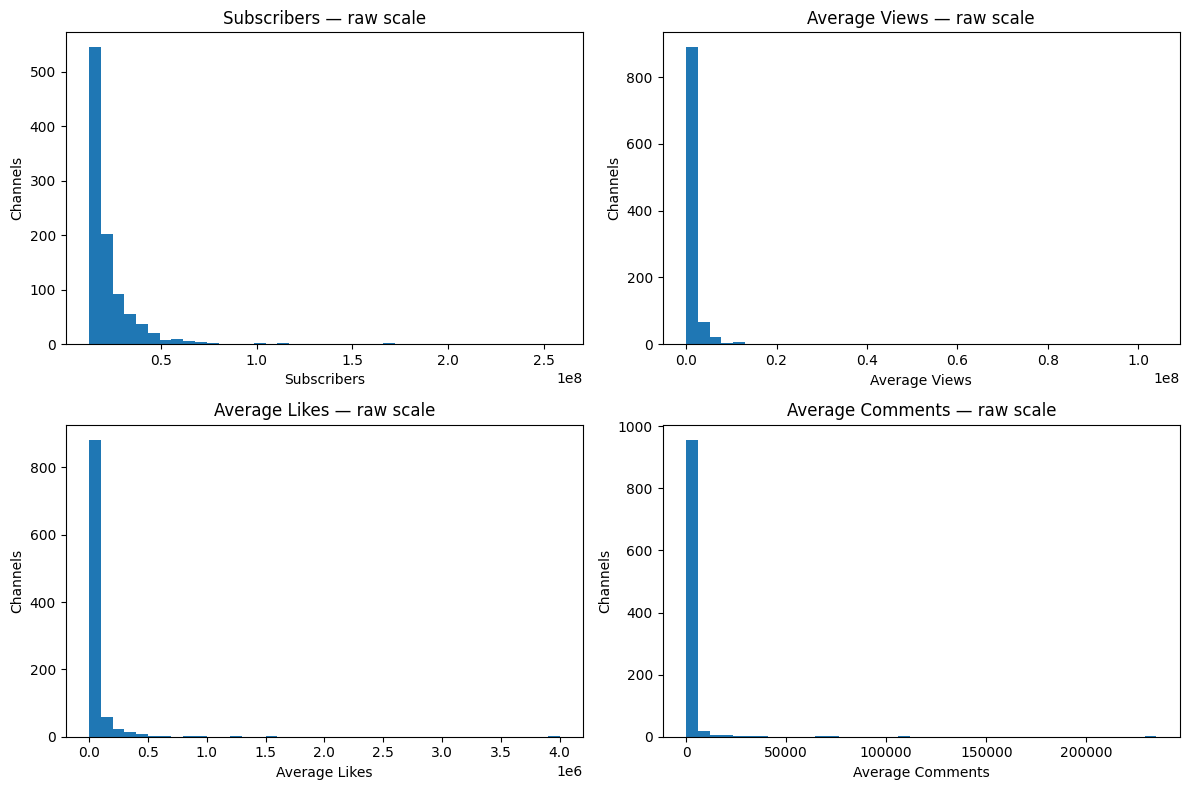

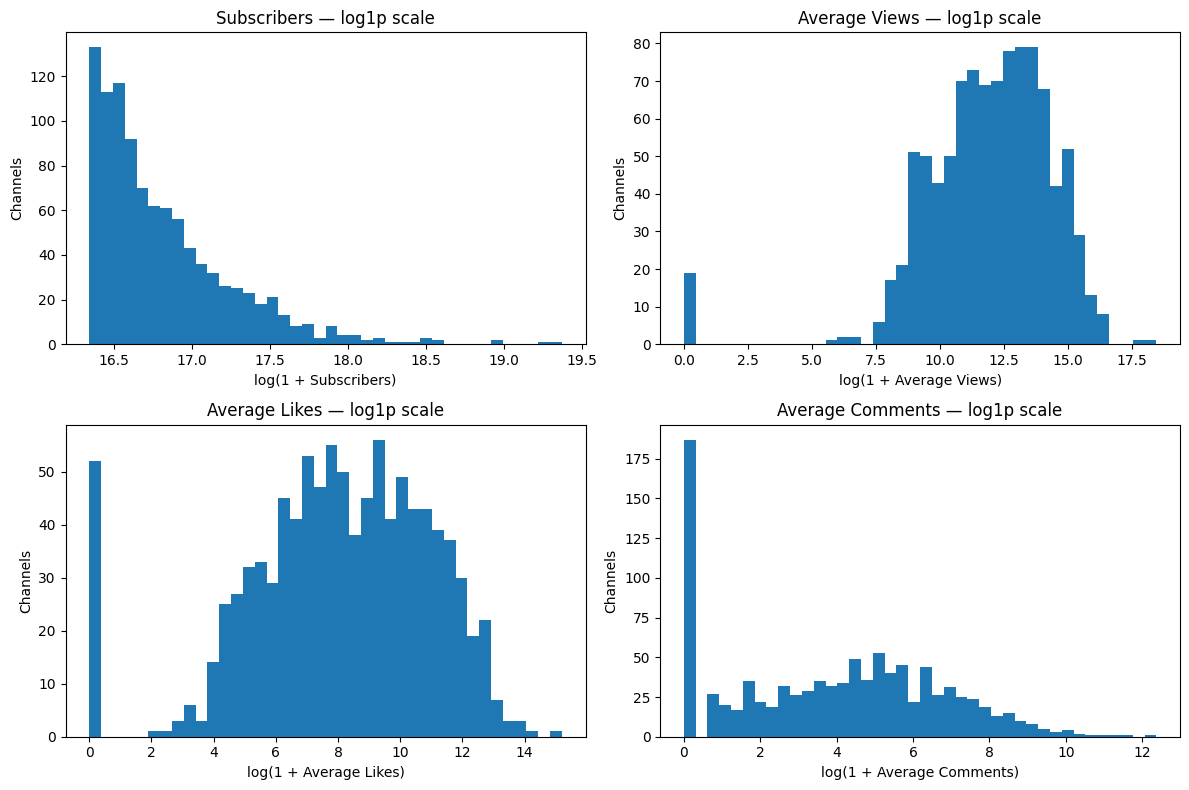

In [10]:
# Raw and log distributions.
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), numeric_cols):
    ax.hist(df_creator[col], bins=40)
    ax.set_title(f"{col} — raw scale")
    ax.set_xlabel(col)
    ax.set_ylabel("Channels")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), numeric_cols):
    ax.hist(np.log1p(df_creator[col]), bins=40)
    ax.set_title(f"{col} — log1p scale")
    ax.set_xlabel(f"log(1 + {col})")
    ax.set_ylabel("Channels")
plt.tight_layout()
plt.show()

In [11]:
# Concentration metrics.
def gini_coefficient(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if np.any(x < 0):
        raise ValueError("Gini helper expects nonnegative values")
    if x.sum() == 0:
        return 0.0
    x = np.sort(x)
    n = len(x)
    cum = np.cumsum(x)
    return (n + 1 - 2 * np.sum(cum) / cum[-1]) / n

def top_share(series, frac):
    s = pd.Series(series).dropna().sort_values(ascending=False)
    n = max(1, int(np.ceil(len(s) * frac)))
    return s.iloc[:n].sum() / s.sum()

concentration = []
for col in numeric_cols:
    concentration.append({
        "feature": col,
        "top_1_pct_share": top_share(df_creator[col], .01),
        "top_5_pct_share": top_share(df_creator[col], .05),
        "top_10_pct_share": top_share(df_creator[col], .10),
        "gini": gini_coefficient(df_creator[col]),
    })
display(pd.DataFrame(concentration).set_index("feature"))

,top_1_pct_share,top_5_pct_share,top_10_pct_share,gini
feature,,,,
Subscribers,0.0654,0.1714,0.2613,0.2774
Average Views,0.2451,0.4875,0.6491,0.7845
Average Likes,0.2661,0.5507,0.7207,0.8354
Average Comments,0.4976,0.7581,0.8615,0.9099



Category


,count
Category,
Missing,333
Music & Dance,202
Movies,147
Animation,126
Daily vlogs,34
News & Politics,31
Video games,29
Education,20
Toys,14



Country


,count
Country,
United States,269
India,245
Missing,183
Brazil,61
Mexico,58
Indonesia,39
Russia,25
Thailand,18
Philippines,14



Content Type


,count
Content Type,
Missing,672
Humor,102
Animation,84
Video games,52
Toys,39
Movies,35
Health & Self Help,4
Autos & Vehicles,3
Fashion,1


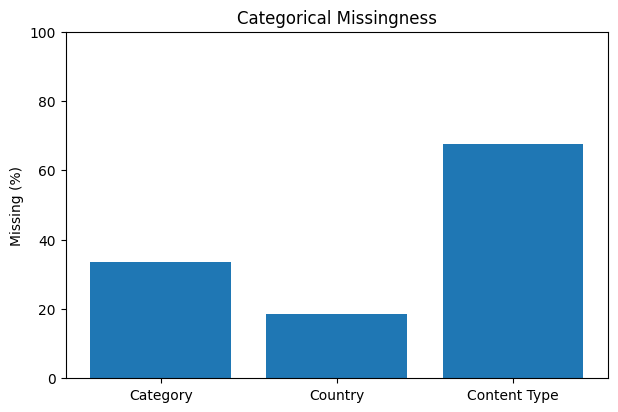

In [12]:
# Categorical frequencies and missingness.
for col in ["Category", "Country", "Content Type"]:
    print(f"\n{col}")
    display(df_creator[col].fillna("Missing").value_counts().head(15).to_frame("count"))

missing_rates = df_creator[["Category", "Country", "Content Type"]].isna().mean().mul(100)
plt.figure(figsize=(7, 4.5))
plt.bar(missing_rates.index, missing_rates.values)
plt.ylabel("Missing (%)")
plt.title("Categorical Missingness")
plt.ylim(0, 100)
plt.show()

In [13]:
# Missingness pattern table.
miss_pattern = pd.DataFrame({
    "Category_missing": df_creator["Category"].isna(),
    "Country_missing": df_creator["Country"].isna(),
    "ContentType_missing": df_creator["Content Type"].isna(),
})
display(miss_pattern.value_counts().to_frame("count"))

nested_violation = ((df_creator["Category"].isna()) & (df_creator["Content Type"].notna())).sum()
print("Content Type known while Category missing:", nested_violation)

count
Category_missing Country_missing ContentType_missing       
False            False           True                   288
True             False           True                   274
False            False           False                  249
                 True            False                   73
True             True            True                    59
False            True            True                    51

Content Type known while Category missing: 0


# 5. Bivariate & Multivariate EDA

In [14]:
# Pearson, Spearman, and log-space correlations.
raw_pearson = df_creator[numeric_cols].corr(method="pearson")
raw_spearman = df_creator[numeric_cols].corr(method="spearman")
log_df = np.log1p(df_creator[numeric_cols])
log_pearson = log_df.corr(method="pearson")

print("Raw Pearson")
display(raw_pearson)
print("Spearman")
display(raw_spearman)
print("Log1p Pearson")
display(log_pearson)

Raw Pearson


,Subscribers,Average Views,Average Likes,Average Comments
Subscribers,1.0000,0.3511,0.2984,0.1059
Average Views,0.3511,1.0000,0.9420,0.3800
Average Likes,0.2984,0.9420,1.0000,0.4723
Average Comments,0.1059,0.3800,0.4723,1.0000


Spearman


,Subscribers,Average Views,Average Likes,Average Comments
Subscribers,1.0000,0.0854,0.0338,-0.0463
Average Views,0.0854,1.0000,0.8591,0.6079
Average Likes,0.0338,0.8591,1.0000,0.7863
Average Comments,-0.0463,0.6079,0.7863,1.0000


Log1p Pearson


,Subscribers,Average Views,Average Likes,Average Comments
Subscribers,1.0000,0.0599,0.0485,-0.0585
Average Views,0.0599,1.0000,0.7862,0.5757
Average Likes,0.0485,0.7862,1.0000,0.7331
Average Comments,-0.0585,0.5757,0.7331,1.0000


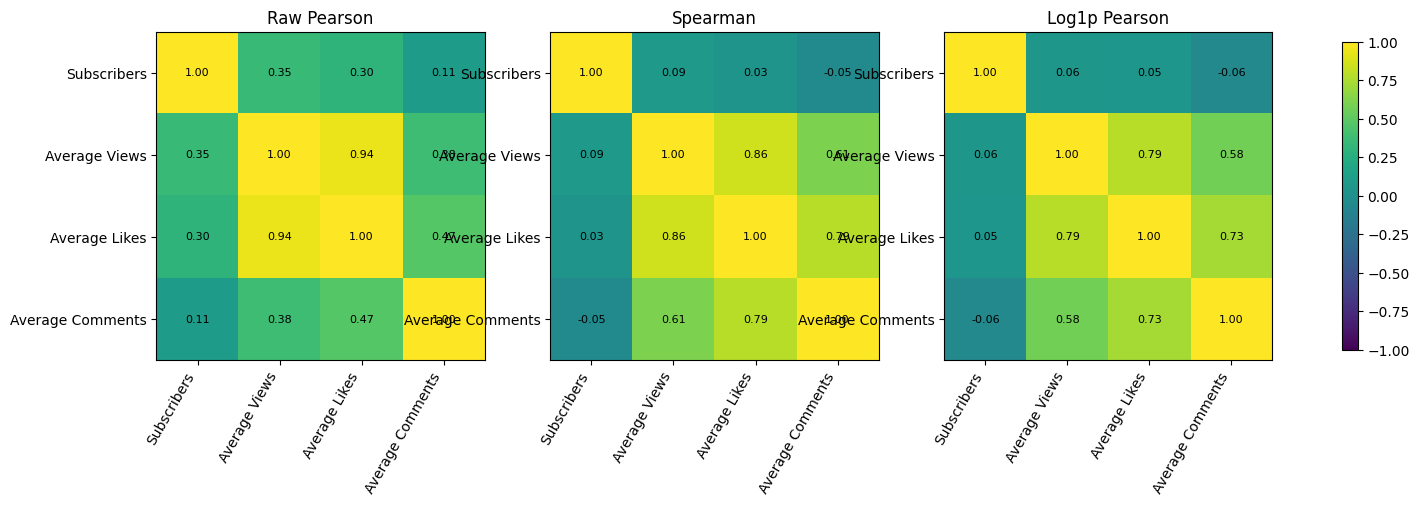

In [15]:
# Correlation heatmaps (matplotlib only).
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, mat, title in zip(
    axes,
    [raw_pearson, raw_spearman, log_pearson],
    ["Raw Pearson", "Spearman", "Log1p Pearson"]
):
    im = ax.imshow(mat.values, vmin=-1, vmax=1)
    ax.set_xticks(range(len(mat.columns)))
    ax.set_yticks(range(len(mat.index)))
    ax.set_xticklabels(mat.columns, rotation=60, ha="right")
    ax.set_yticklabels(mat.index)
    ax.set_title(title)
    for i in range(len(mat.index)):
        for j in range(len(mat.columns)):
            ax.text(j, i, f"{mat.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=.8)
plt.show()

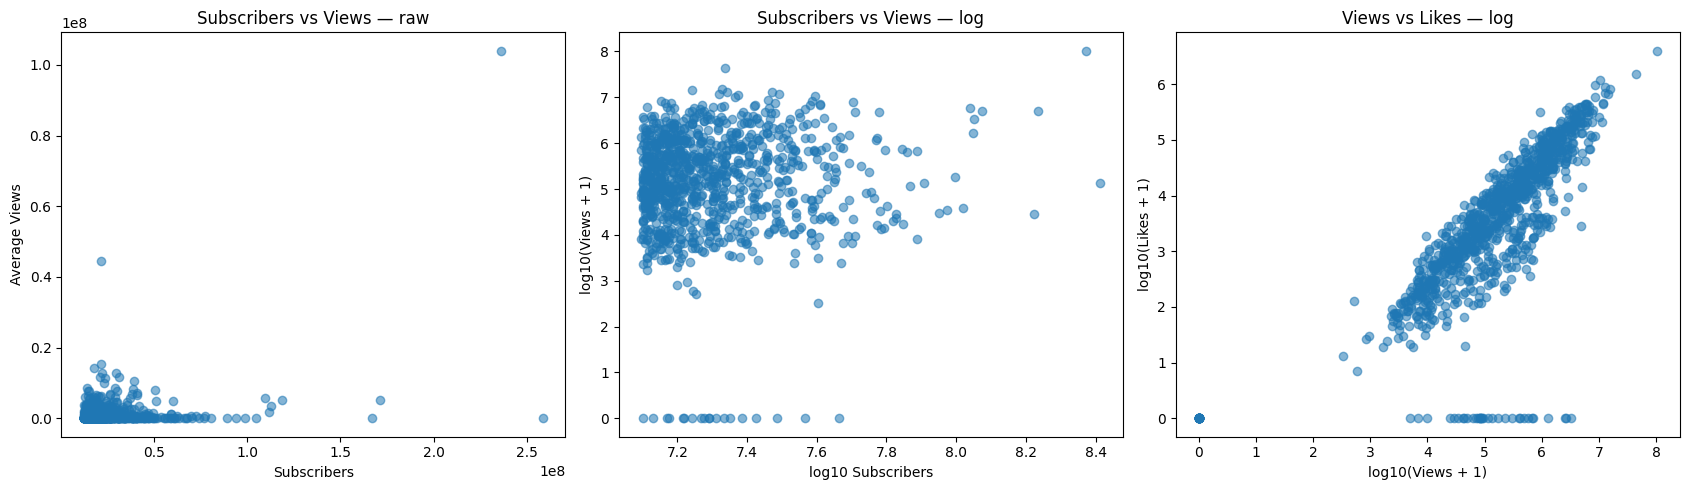

In [16]:
# Key scatterplots.
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
axes[0].scatter(df_creator["Subscribers"], df_creator["Average Views"], alpha=.55)
axes[0].set_xlabel("Subscribers")
axes[0].set_ylabel("Average Views")
axes[0].set_title("Subscribers vs Views — raw")

axes[1].scatter(np.log10(df_creator["Subscribers"]), np.log10(df_creator["Average Views"] + 1), alpha=.55)
axes[1].set_xlabel("log10 Subscribers")
axes[1].set_ylabel("log10(Views + 1)")
axes[1].set_title("Subscribers vs Views — log")

axes[2].scatter(np.log10(df_creator["Average Views"] + 1), np.log10(df_creator["Average Likes"] + 1), alpha=.55)
axes[2].set_xlabel("log10(Views + 1)")
axes[2].set_ylabel("log10(Likes + 1)")
axes[2].set_title("Views vs Likes — log")
plt.tight_layout()
plt.show()

In [17]:
# Tail sensitivity: subscriber-view Pearson with and without the single max-view creator.
r_all = df_creator[["Subscribers", "Average Views"]].corr().iloc[0,1]
max_view_idx = df_creator["Average Views"].idxmax()
r_without_max = df_creator.drop(index=max_view_idx)[["Subscribers", "Average Views"]].corr().iloc[0,1]
r_spearman = df_creator[["Subscribers", "Average Views"]].corr(method="spearman").iloc[0,1]
r_log = np.log1p(df_creator[["Subscribers", "Average Views"]]).corr().iloc[0,1]

pd.DataFrame({
    "measure": ["Raw Pearson", "Raw Pearson without max-view creator", "Spearman", "Log Pearson"],
    "correlation": [r_all, r_without_max, r_spearman, r_log]
})

,measure,correlation
0,Raw Pearson,0.3511
1,Raw Pearson without max-view creator,0.0698
2,Spearman,0.0854
3,Log Pearson,0.0599


,n,median_subscribers,median_views,median_likes,median_comments
Category,,,,,
Video games,29,"20,700,000.0000","861,100.0000","42,200.0000",893.0000
Humor,12,"14,800,000.0000","454,500.0000","17,500.0000",238.5000
Animation,126,"17,400,000.0000","299,650.0000","4,600.0000",110.5000
Movies,147,"17,800,000.0000","292,800.0000","5,000.0000",92.0000
Daily vlogs,34,"16,350,000.0000","254,100.0000","3,400.0000",69.0000
Education,20,"21,500,000.0000","172,650.0000","2,250.0000",0.0000
Food & Drinks,11,"16,400,000.0000","157,000.0000","3,500.0000",430.0000
Toys,14,"20,500,000.0000","111,000.0000",789.0000,0.0000
Music & Dance,202,"18,850,000.0000","64,300.0000","1,550.0000",36.0000


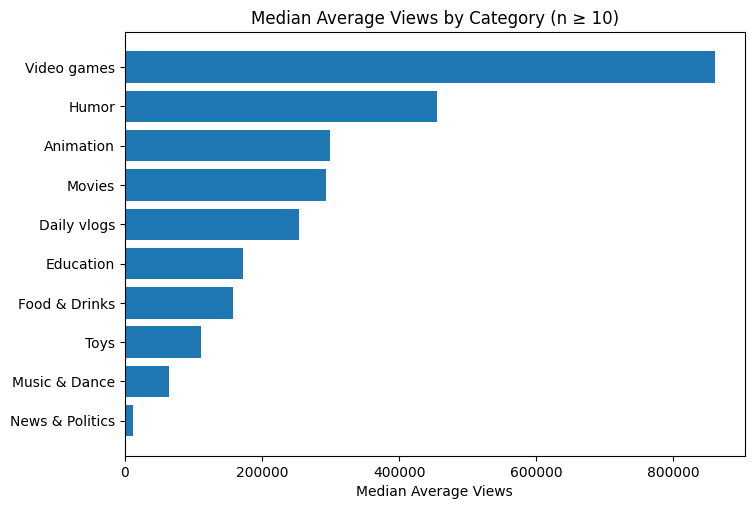

In [18]:
# Category medians for sufficiently represented categories.
cat_profile = (
    df_creator.dropna(subset=["Category"])
              .groupby("Category")
              .agg(
                  n=("Channel Name", "size"),
                  median_subscribers=("Subscribers", "median"),
                  median_views=("Average Views", "median"),
                  median_likes=("Average Likes", "median"),
                  median_comments=("Average Comments", "median"),
              )
              .query("n >= 10")
              .sort_values("median_views", ascending=False)
)
display(cat_profile)

plt.figure(figsize=(8, 5.5))
plot_cat = cat_profile.sort_values("median_views")
plt.barh(plot_cat.index, plot_cat["median_views"])
plt.xlabel("Median Average Views")
plt.title("Median Average Views by Category (n ≥ 10)")
plt.show()

# 6. Outlier, Sentinel & Influence Analysis

In [19]:
# Tukey IQR screening on raw and log scales.
def iqr_flags(series, k=1.5):
    s = pd.Series(series).dropna()
    q1, q3 = s.quantile([.25, .75])
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    flags = (series < lo) | (series > hi)
    return lo, hi, flags.fillna(False)

outlier_rows = []
for col in numeric_cols:
    lo, hi, flags = iqr_flags(df_creator[col])
    llo, lhi, lflags = iqr_flags(np.log1p(df_creator[col]))
    outlier_rows.append({
        "feature": col,
        "raw_lower": lo,
        "raw_upper": hi,
        "raw_flags": int(flags.sum()),
        "log_flags": int(lflags.sum()),
    })
display(pd.DataFrame(outlier_rows).set_index("feature"))

,raw_lower,raw_upper,raw_flags,log_flags
feature,,,,
Subscribers,"-362,500.0000","39,537,500.0000",80,35
Average Views,"-1,226,337.5000","2,139,762.5000",119,19
Average Likes,"-41,356.8750","70,334.1250",146,52
Average Comments,-561.7500,944.2500,160,0


In [20]:
# Sentinel-zero pattern.
zero_triplet = (
    df_creator["Average Views"].eq(0)
    & df_creator["Average Likes"].eq(0)
    & df_creator["Average Comments"].eq(0)
)

print("0/0/0 engagement triplets:", zero_triplet.sum())
display(df_creator.loc[zero_triplet, [
    "Rank", "Channel Name", "Subscribers", "Average Views", "Average Likes", "Average Comments"
]].sort_values("Subscribers", ascending=False))

# Preserve master creator data, but mark these engagement measurements unavailable.
df_creator["Engagement_Available"] = (~zero_triplet).astype("int8")
df_engagement = df_creator.loc[~zero_triplet].copy().reset_index(drop=True)

assert len(df_engagement) == 975
print("Engagement-valid rows:", len(df_engagement))

0/0/0 engagement triplets: 19


,Rank,Channel Name,Subscribers,Average Views,Average Likes,Average Comments
51,52,Felipe Neto,"46,200,000.0000",0.0000,0.0000,0.0000
101,102,Maroon 5,"36,800,000.0000",0.0000,0.0000,0.0000
158,160,jacksepticeye,"30,700,000.0000",0.0000,0.0000,0.0000
211,213,Nicki Minaj,"26,600,000.0000",0.0000,0.0000,0.0000
255,257,Ian Lucas,"24,300,000.0000",0.0000,0.0000,0.0000
302,304,Khan GS Research Centre,"22,500,000.0000",0.0000,0.0000,0.0000
330,332,LazarBeam,"21,500,000.0000",0.0000,0.0000,0.0000
372,376,How Ridiculous,"20,400,000.0000",0.0000,0.0000,0.0000
412,416,TheOdd1sOut,"19,500,000.0000",0.0000,0.0000,0.0000
415,419,Познаватель,"19,500,000.0000",0.0000,0.0000,0.0000


Engagement-valid rows: 975


In [21]:
# Multivariate anomaly ranking in robust-scaled log space.
X_anom = RobustScaler().fit_transform(np.log1p(df_creator[numeric_cols]))
iso = IsolationForest(n_estimators=200, contamination="auto", random_state=SEED)
iso.fit(X_anom)
df_creator["Isolation_score"] = iso.score_samples(X_anom)

anomalies = df_creator.nsmallest(12, "Isolation_score")[[
    "Rank", "Channel Name", "Subscribers", "Average Views", "Average Likes", "Average Comments", "Isolation_score"
]]
display(anomalies)

,Rank,Channel Name,Subscribers,Average Views,Average Likes,Average Comments,Isolation_score
1,2,MrBeast,"236,100,000.0000","104,000,000.0000","4,000,000.0000","74,000.0000",-0.7622
51,52,Felipe Neto,"46,200,000.0000",0.0000,0.0000,0.0000,-0.6981
101,102,Maroon 5,"36,800,000.0000",0.0000,0.0000,0.0000,-0.6854
2,3,Cocomelon - Nursery Rhymes,"171,400,000.0000","5,100,000.0000","57,100.0000",0.0000,-0.6767
158,160,jacksepticeye,"30,700,000.0000",0.0000,0.0000,0.0000,-0.6725
81,82,Total Gaming,"39,300,000.0000","10,500,000.0000","1,200,000.0000","111,000.0000",-0.6667
967,974,CaseyNeistat,"12,600,000.0000",0.0000,0.0000,0.0000,-0.6643
211,213,Nicki Minaj,"26,600,000.0000",0.0000,0.0000,0.0000,-0.6611
323,325,Bizarrap,"21,700,000.0000","44,500,000.0000","1,500,000.0000","66,000.0000",-0.6582
854,861,EnriqueIglesiasVEVO,"13,500,000.0000",0.0000,0.0000,0.0000,-0.6547


In [22]:
# Cook's distance for a simple log(Views) ~ log(Subscribers) influence diagnostic.
influence_df = df_engagement[["Channel Name", "Subscribers", "Average Views"]].copy()
X_sm = sm.add_constant(np.log(influence_df["Subscribers"]))
y_sm = np.log(influence_df["Average Views"])
ols_sm = sm.OLS(y_sm, X_sm).fit()
cooks = ols_sm.get_influence().cooks_distance[0]
influence_df["Cooks_D"] = cooks

display(influence_df.nlargest(10, "Cooks_D"))
print("Heuristic 4/n threshold:", 4 / len(influence_df))

,Channel Name,Subscribers,Average Views,Cooks_D
1,MrBeast,"236,100,000.0000","104,000,000.0000",0.1200
3,SET India,"167,100,000.0000","27,900.0000",0.0213
2,Cocomelon - Nursery Rhymes,"171,400,000.0000","5,100,000.0000",0.0197
76,TEDx Talks,"40,100,000.0000",334.0000,0.0177
14,Zee TV,"77,000,000.0000","8,200.0000",0.0161
7,Vlad and Niki,"109,600,000.0000","5,800,000.0000",0.0155
4,✿ Kids Diana Show,"118,500,000.0000","5,100,000.0000",0.0151
48,ABS-CBN Entertainment,"46,700,000.0000","2,500.0000",0.0118
5,Like Nastya,"112,600,000.0000","3,400,000.0000",0.0104
8,Zee Music Company,"104,500,000.0000","38,000.0000",0.0087


Heuristic 4/n threshold: 0.0041025641025641026


### Outlier-treatment policy

- **Structural errors:** remove / resolve.
- **19 probable sentinel-zero engagement records:** keep creator metadata, but exclude from engagement-dependent analysis.
- **Legitimate superstar extremes:** keep; prefer log transformation and robustness diagnostics over automatic deletion.
- **Influential observations:** inspect and sensitivity-test rather than delete automatically.
- **Winsorization:** use only as a sensitivity experiment, not the default representation.

# 7. Feature Engineering

In [23]:
# Candidate engineered engagement features.
df_engagement["View_Efficiency"] = df_engagement["Average Views"] / df_engagement["Subscribers"]
df_engagement["Like_Rate"] = df_engagement["Average Likes"] / df_engagement["Average Views"]
df_engagement["Comment_Rate"] = df_engagement["Average Comments"] / df_engagement["Average Views"]
df_engagement["Interaction_Rate"] = (
    df_engagement["Average Likes"] + df_engagement["Average Comments"]
) / df_engagement["Average Views"]
df_engagement["Has_Likes"] = (df_engagement["Average Likes"] > 0).astype("int8")
df_engagement["Has_Comments"] = (df_engagement["Average Comments"] > 0).astype("int8")

df_engagement["log_View_Efficiency"] = np.log(df_engagement["View_Efficiency"])

rate_cols = ["View_Efficiency", "Like_Rate", "Comment_Rate", "Interaction_Rate"]
display(df_engagement[rate_cols].describe(percentiles=[.5, .9, .95, .99]).T)
print("Raw View Efficiency skew:", df_engagement["View_Efficiency"].skew())
print("Log View Efficiency skew:", df_engagement["log_View_Efficiency"].skew())
print("Spearman Like Rate vs Interaction Rate:",
      df_engagement[["Like_Rate", "Interaction_Rate"]].corr(method="spearman").iloc[0,1])

,count,mean,std,min,50%,90%,95%,99%,max
View_Efficiency,975.0000,0.0459,0.1068,0.0000,0.0103,0.1348,0.2040,0.4480,2.0507
Like_Rate,975.0000,0.0378,0.0342,0.0000,0.0301,0.0802,0.0983,0.1536,0.3423
Comment_Rate,975.0000,0.0015,0.0089,0.0000,0.0005,0.0028,0.0039,0.0099,0.2510
Interaction_Rate,975.0000,0.0393,0.0388,0.0000,0.0310,0.0816,0.0999,0.1559,0.5933


Raw View Efficiency skew: 8.758591954569766
Log View Efficiency skew: -0.2342257726982573
Spearman Like Rate vs Interaction Rate: 0.9989358432174329


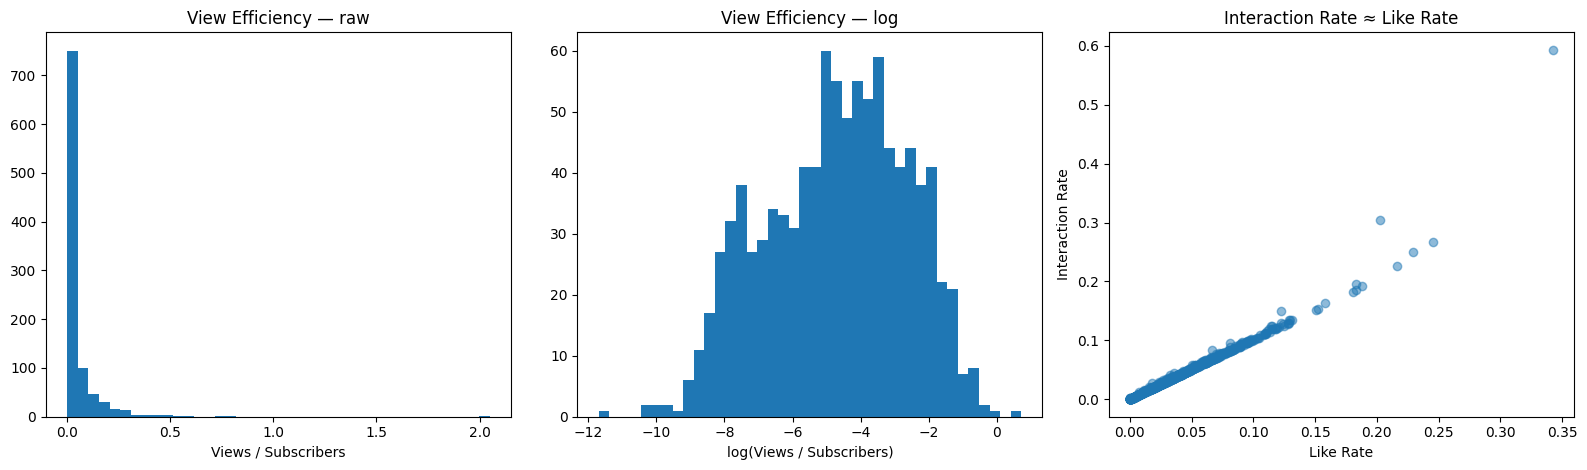

In [24]:
# Visualize key engineered-feature behavior.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
axes[0].hist(df_engagement["View_Efficiency"], bins=40)
axes[0].set_title("View Efficiency — raw")
axes[0].set_xlabel("Views / Subscribers")

axes[1].hist(df_engagement["log_View_Efficiency"], bins=40)
axes[1].set_title("View Efficiency — log")
axes[1].set_xlabel("log(Views / Subscribers)")

axes[2].scatter(df_engagement["Like_Rate"], df_engagement["Interaction_Rate"], alpha=.5)
axes[2].set_title("Interaction Rate ≈ Like Rate")
axes[2].set_xlabel("Like Rate")
axes[2].set_ylabel("Interaction Rate")
plt.tight_layout()
plt.show()

# 8. Feature Selection, Multicollinearity & PCA

In [25]:
# VIF helper.
def vif_table(frame):
    X = pd.DataFrame(frame).dropna().astype(float)
    X = sm.add_constant(X)
    rows = []
    for i, col in enumerate(X.columns):
        if col == "const":
            continue
        rows.append({"feature": col, "VIF": variance_inflation_factor(X.values, i)})
    return pd.DataFrame(rows)

core_log = pd.DataFrame({
    "log_subscribers": np.log(df_engagement["Subscribers"]),
    "log_views": np.log(df_engagement["Average Views"]),
    "log1p_likes": np.log1p(df_engagement["Average Likes"]),
    "log1p_comments": np.log1p(df_engagement["Average Comments"]),
})

display(vif_table(core_log))

# Demonstrate exact redundancy when log View Efficiency is added.
redundant_log = core_log.copy()
redundant_log["log_view_efficiency"] = df_engagement["log_View_Efficiency"].values
try:
    display(vif_table(redundant_log))
except Exception as e:
    print("VIF computation confirms singular / exact redundancy:", e)

,feature,VIF
0,log_subscribers,1.0297
1,log_views,2.4560
2,log1p_likes,3.3539
3,log1p_comments,2.1704


,feature,VIF
0,log_subscribers,inf
1,log_views,inf
2,log1p_likes,3.3539
3,log1p_comments,2.1704
4,log_view_efficiency,inf


In [26]:
# PCA on standardized core logged measurements.
X_core_scaled = StandardScaler().fit_transform(core_log)
pca4 = PCA().fit(X_core_scaled)

pca_summary = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(4)],
    "explained_variance_ratio": pca4.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(pca4.explained_variance_ratio_),
})
display(pca_summary)

loadings = pd.DataFrame(
    pca4.components_.T,
    index=core_log.columns,
    columns=[f"PC{i+1}" for i in range(4)]
)
display(loadings)

,PC,explained_variance_ratio,cumulative_variance
0,PC1,0.5984,0.5984
1,PC2,0.2541,0.8524
2,PC3,0.0982,0.9506
3,PC4,0.0494,1.0000


,PC1,PC2,PC3,PC4
log_subscribers,0.0334,0.9852,0.1652,-0.0300
log_views,0.5705,0.0751,-0.6526,-0.4929
log1p_likes,0.6041,0.0153,-0.0697,0.7937
log1p_comments,0.5555,-0.1531,0.7362,-0.3551


### Feature-selection decisions

**Exclude from core ML:**

- `Channel Name` — identifier
- `Rank` — almost perfectly redundant with subscriber ordering
- `Interaction_Rate` — exact sum of `Like_Rate + Comment_Rate`

**Do not simultaneously use** `log_subscribers`, `log_views`, and `log_view_efficiency` in ordinary linear regression because the third is algebraically determined by the first two.

**Content Type** is retained only as an ablation candidate because of severe missingness and overlap with Category.

# 9. Creator Clustering

,k,inertia,silhouette
0,2,"2,248.9091",0.3775
1,3,"1,783.9048",0.3583
2,4,"1,457.3758",0.2974
3,5,"1,286.5512",0.3096
4,6,"1,128.6322",0.3008
5,7,"1,007.1939",0.3099
6,8,909.0079,0.2961


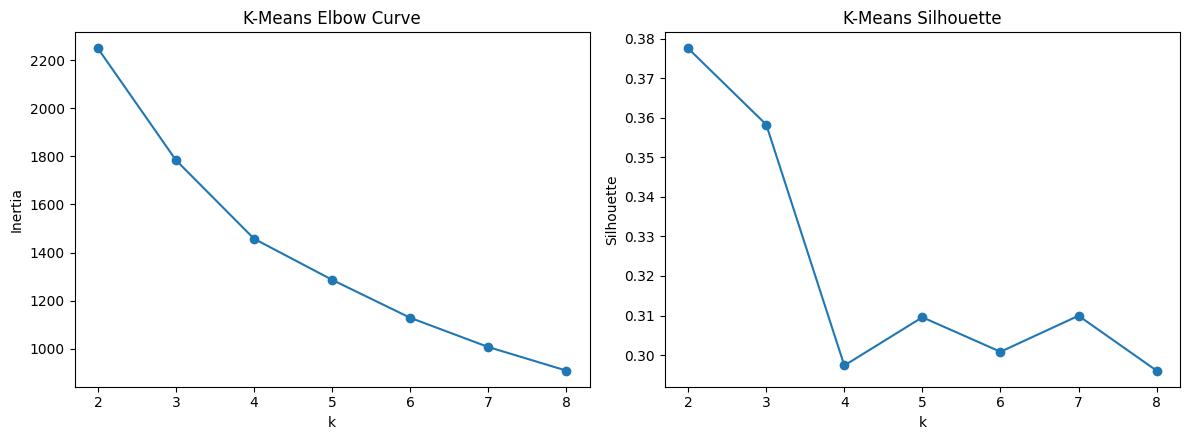

In [27]:
# Primary K-Means matrix: quantitative scale + engagement only.
cluster_features = pd.DataFrame({
    "log_subscribers": np.log(df_engagement["Subscribers"]),
    "log_views": np.log(df_engagement["Average Views"]),
    "log1p_likes": np.log1p(df_engagement["Average Likes"]),
    "log1p_comments": np.log1p(df_engagement["Average Comments"]),
})

cluster_scaler = StandardScaler()
X_cluster = cluster_scaler.fit_transform(cluster_features)

cluster_results = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=50, random_state=SEED)
    labels = km.fit_predict(X_cluster)
    cluster_results.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(X_cluster, labels),
    })
cluster_results = pd.DataFrame(cluster_results)
display(cluster_results)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(cluster_results["k"], cluster_results["inertia"], marker="o")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("K-Means Elbow Curve")
axes[1].plot(cluster_results["k"], cluster_results["silhouette"], marker="o")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette")
axes[1].set_title("K-Means Silhouette")
plt.tight_layout()
plt.show()

In [28]:
# Recommended k=3 business segmentation.
km3 = KMeans(n_clusters=3, n_init=50, random_state=SEED)
labels3 = km3.fit_predict(X_cluster)
df_engagement["Cluster"] = labels3

# Rename by centroid interpretation rather than arbitrary numeric IDs.
centers = pd.DataFrame(km3.cluster_centers_, columns=["Subscribers", "Views", "Likes", "Comments"])
print("Standardized centroids")
display(centers)

# Identify labels by pattern.
engagement_leader = centers[["Views", "Likes", "Comments"]].mean(axis=1).idxmax()
mega_audience = centers["Subscribers"].idxmax()
lower_activity = ({0,1,2} - {engagement_leader, mega_audience}).pop()

cluster_names = {
    lower_activity: "Lower-Activity Top-Tier",
    engagement_leader: "Current Engagement Leaders",
    mega_audience: "Mega-Audience / Under-Activated",
}
df_engagement["Cluster_Name"] = df_engagement["Cluster"].map(cluster_names)

cluster_profile = df_engagement.groupby("Cluster_Name").agg(
    n=("Channel Name", "size"),
    median_rank=("Rank", "median"),
    median_subscribers=("Subscribers", "median"),
    median_views=("Average Views", "median"),
    median_likes=("Average Likes", "median"),
    median_comments=("Average Comments", "median"),
    median_view_efficiency=("View_Efficiency", "median"),
)
display(cluster_profile)

Standardized centroids


,Subscribers,Views,Likes,Comments
0,-0.4723,-0.7573,-0.8062,-0.6584
1,-0.1620,0.7762,0.8384,0.8420
2,1.5921,-0.2867,-0.3382,-0.7072


,n,median_rank,median_subscribers,median_views,median_likes,median_comments,median_view_efficiency
Cluster_Name,,,,,,,
Current Engagement Leaders,433,531.0000,"17,200,000.0000","934,000.0000","34,800.0000",516.0000,0.0456
Lower-Activity Top-Tier,384,631.5000,"15,800,000.0000","43,100.0000",590.5000,6.0000,0.0027
Mega-Audience / Under-Activated,158,94.5000,"38,350,000.0000","86,850.0000","1,100.0000",5.0000,0.0018


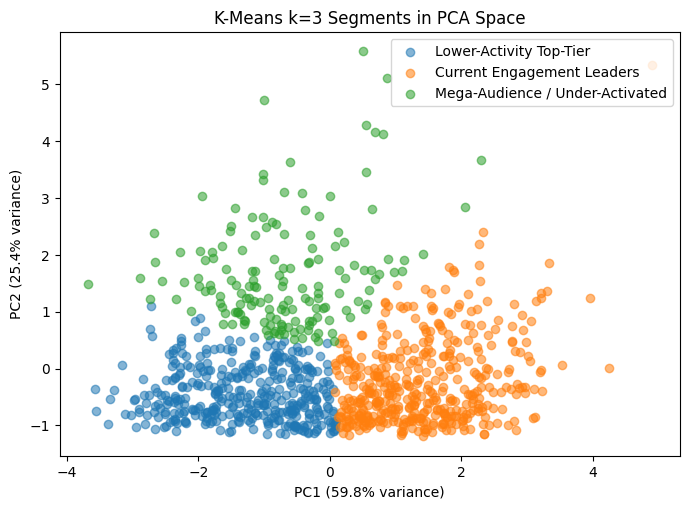

ARI: full 4D K-Means vs 2D PCA K-Means = 0.9900914749068613
ARI: K-Means vs Ward hierarchical = 0.3665143024900651


In [29]:
# PCA visualization and stability check.
pca2 = PCA(n_components=2)
Xp = pca2.fit_transform(X_cluster)

plt.figure(figsize=(8, 5.5))
for label, name in cluster_names.items():
    mask = labels3 == label
    plt.scatter(Xp[mask, 0], Xp[mask, 1], alpha=.55, label=name)
plt.xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("K-Means k=3 Segments in PCA Space")
plt.legend()
plt.show()

km_pca = KMeans(n_clusters=3, n_init=50, random_state=SEED)
labels_pca = km_pca.fit_predict(Xp)
print("ARI: full 4D K-Means vs 2D PCA K-Means =", adjusted_rand_score(labels3, labels_pca))

agg = AgglomerativeClustering(n_clusters=3, linkage="ward")
labels_agg = agg.fit_predict(X_cluster)
print("ARI: K-Means vs Ward hierarchical =", adjusted_rand_score(labels3, labels_agg))

# 10. Synthetic Revenue Target & Leakage Audit

In [30]:
# Transparent pedagogical target — NOT observed creator revenue/income.
ILLUSTRATIVE_RPM = 3.0
df_engagement["Revenue_Proxy_RPM3"] = df_engagement["Average Views"] / 1000 * ILLUSTRATIVE_RPM

y_proxy = df_engagement["Revenue_Proxy_RPM3"]
print("Synthetic target summary")
display(y_proxy.describe(percentiles=[.5, .9, .95, .99]).to_frame("Revenue_Proxy_RPM3"))

Synthetic target summary


,Revenue_Proxy_RPM3
count,975.0000
mean,"3,125.7800"
std,"11,996.7434"
min,1.0020
50%,585.6000
90%,"8,100.0000"
95%,"13,800.0000"
99%,"30,612.0000"
max,"312,000.0000"


### Leakage lineage

The synthetic target is

$$
Y_{proxy}=\frac{AverageViews}{1000}\times 3.
$$

Therefore `Average Views` is **literally inside the target formula**. A model given Average Views can trivially reconstruct the target and is invalid as a predictive model.

For the strict leakage-restricted regression experiment, exclude:

- Average Views / log Views
- View Efficiency / log View Efficiency
- Like Rate
- Comment Rate
- Interaction Rate
- Rank
- Channel Name

Core predictors:

- Subscribers
- Average Likes
- Average Comments
- Category
- Country

`Content Type` is evaluated only by ablation.

In [31]:
# Demonstrate target leakage explicitly.
X_leak = df_engagement[["Average Views"]].to_numpy()
y = df_engagement["Revenue_Proxy_RPM3"].to_numpy()
leak_model = LinearRegression().fit(X_leak, y)
leak_pred = leak_model.predict(X_leak)

print("Leaked coefficient:", leak_model.coef_[0])
print("Leaked intercept:", leak_model.intercept_)
print("Leaked MAE:", mean_absolute_error(y, leak_pred))
print("Leaked RMSE:", mean_squared_error(y, leak_pred) ** .5)
print("Leaked R2:", r2_score(y, leak_pred))

Leaked coefficient: 0.002999999999999999
Leaked intercept: 9.094947017729282e-13
Leaked MAE: 1.0635378617670983e-12
Leaked RMSE: 2.6299801963614027e-12
Leaked R2: 1.0


# 11. Supervised Modeling — Frozen Split & Leakage-Safe Pipelines

In [32]:
# Fixed regression feature set and target.
REG_FEATURES = ["Subscribers", "Average Likes", "Average Comments", "Category", "Country"]
NUM_FEATURES = ["Subscribers", "Average Likes", "Average Comments"]
CAT_FEATURES = ["Category", "Country"]

X = df_engagement[REG_FEATURES].copy()
y = df_engagement["Revenue_Proxy_RPM3"].copy()

# Quantile-based stratification balances the highly skewed target across splits.
strata = pd.qcut(y.rank(method="first"), q=5, labels=False)
X_dev, X_test, y_dev, y_test, strata_dev, strata_test = train_test_split(
    X, y, strata,
    test_size=.20,
    stratify=strata,
    random_state=SEED,
)

print("Development:", len(X_dev), "Holdout:", len(X_test))

Development: 780 Holdout: 195


In [33]:
# Reusable preprocessing objects.
def make_onehot():
    # sparse_output is available in modern sklearn / current Colab.
    return OneHotEncoder(
        handle_unknown="infrequent_if_exist",
        min_frequency=5,
        drop="first",
        sparse_output=False,
    )

linear_preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("scale", StandardScaler()),
    ]), NUM_FEATURES),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", make_onehot()),
    ]), CAT_FEATURES),
], sparse_threshold=0)

tree_preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ]), NUM_FEATURES),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", make_onehot()),
    ]), CAT_FEATURES),
], sparse_threshold=0)

In [34]:
# Fixed five development folds, stratified by target quintile.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
folds = list(cv.split(X_dev, strata_dev))

def evaluate_cv(estimator, X_data=X_dev, y_data=y_dev, fold_indices=folds):
    rows = []
    for fold, (tr, va) in enumerate(fold_indices, 1):
        model = clone(estimator)
        model.fit(X_data.iloc[tr], y_data.iloc[tr])
        pred = model.predict(X_data.iloc[va])
        rows.append({
            "fold": fold,
            "MAE": mean_absolute_error(y_data.iloc[va], pred),
            "RMSE": mean_squared_error(y_data.iloc[va], pred) ** .5,
            "R2": r2_score(y_data.iloc[va], pred),
        })
    return pd.DataFrame(rows)

def summarize_cv(name, cv_df):
    return {
        "Model": name,
        "CV_MAE": cv_df["MAE"].mean(),
        "CV_RMSE_mean_of_folds": cv_df["RMSE"].mean(),
        "CV_R2_mean": cv_df["R2"].mean(),
        "MAE_SD": cv_df["MAE"].std(ddof=1),
    }

## 11.1 Baselines and linear-family models

In [35]:
# Candidate constructors.
def linear_model(estimator, log_target=True):
    pipe = Pipeline([
        ("prep", linear_preprocessor),
        ("model", estimator),
    ])
    if log_target:
        return TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)
    return pipe

models_linear = {
    "Dummy mean": DummyRegressor(strategy="mean"),
    "Dummy median": DummyRegressor(strategy="median"),
    "Linear raw": linear_model(LinearRegression(), log_target=False),
    "Linear log": linear_model(LinearRegression(), log_target=True),
    "Ridge log": linear_model(Ridge(alpha=10), log_target=True),
    "Lasso log": linear_model(Lasso(alpha=.01, max_iter=10000, random_state=SEED), log_target=True),
    "ElasticNet log": linear_model(ElasticNet(alpha=.03, l1_ratio=.1, max_iter=10000, random_state=SEED), log_target=True),
}

linear_rows = []
linear_fold_results = {}
for name, model in models_linear.items():
    cv_df = evaluate_cv(model)
    linear_fold_results[name] = cv_df
    linear_rows.append(summarize_cv(name, cv_df))
linear_summary = pd.DataFrame(linear_rows).sort_values("CV_MAE")
display(linear_summary)

,Model,CV_MAE,CV_RMSE_mean_of_folds,CV_R2_mean,MAE_SD
6,ElasticNet log,"1,713.8075","6,612.8794",0.5330,409.6538
4,Ridge log,"1,715.3916","6,494.1870",0.5303,393.2463
5,Lasso log,"1,739.7631","6,626.0602",0.5004,418.0624
3,Linear log,"1,783.2822","6,677.7711",0.4379,433.8839
1,Dummy median,"2,889.0146","9,841.7421",-0.1405,516.1189
0,Dummy mean,"3,736.6348","9,451.1003",-0.0057,449.9450
2,Linear raw,"4,094.8255","9,314.4438",-0.0642,171.7417


## 11.2 Decision Tree, Random Forest & Gradient Boosting

,Model,CV_MAE,CV_RMSE_mean_of_folds,CV_R2_mean,MAE_SD
1,Random Forest log,"1,521.0773","7,003.0432",0.5981,630.5779
2,Gradient Boosting log,"1,521.8947","6,900.9832",0.6077,644.6677
0,Decision Tree log,"1,655.7193","7,273.0756",0.5495,626.5191


,Model,CV_MAE,CV_RMSE_mean_of_folds,CV_R2_mean,MAE_SD
7,Random Forest log,"1,521.0773","7,003.0432",0.5981,630.5779
8,Gradient Boosting log,"1,521.8947","6,900.9832",0.6077,644.6677
9,Decision Tree log,"1,655.7193","7,273.0756",0.5495,626.5191
0,ElasticNet log,"1,713.8075","6,612.8794",0.5330,409.6538
1,Ridge log,"1,715.3916","6,494.1870",0.5303,393.2463
2,Lasso log,"1,739.7631","6,626.0602",0.5004,418.0624
3,Linear log,"1,783.2822","6,677.7711",0.4379,433.8839
4,Dummy median,"2,889.0146","9,841.7421",-0.1405,516.1189
5,Dummy mean,"3,736.6348","9,451.1003",-0.0057,449.9450
6,Linear raw,"4,094.8255","9,314.4438",-0.0642,171.7417


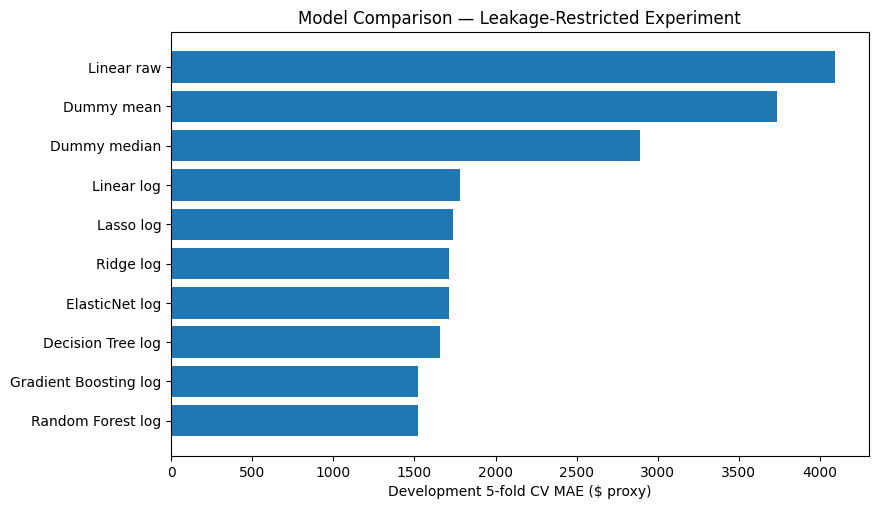

In [36]:
def tree_target_model(estimator, log_target=True):
    pipe = Pipeline([
        ("prep", tree_preprocessor),
        ("model", estimator),
    ])
    if log_target:
        return TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)
    return pipe

models_tree = {
    "Decision Tree log": tree_target_model(
        DecisionTreeRegressor(max_depth=8, min_samples_leaf=15, random_state=SEED), True),
    "Random Forest log": tree_target_model(
        RandomForestRegressor(
            n_estimators=250, max_depth=6, min_samples_leaf=5,
            max_features=.8, random_state=SEED, n_jobs=-1
        ), True),
    "Gradient Boosting log": tree_target_model(
        GradientBoostingRegressor(
            n_estimators=200, learning_rate=.03, max_depth=3,
            min_samples_leaf=5, random_state=SEED
        ), True),
}

tree_rows = []
tree_fold_results = {}
for name, model in models_tree.items():
    cv_df = evaluate_cv(model)
    tree_fold_results[name] = cv_df
    tree_rows.append(summarize_cv(name, cv_df))
tree_summary = pd.DataFrame(tree_rows).sort_values("CV_MAE")
display(tree_summary)

all_dev_results = pd.concat([linear_summary, tree_summary], ignore_index=True).sort_values("CV_MAE")
display(all_dev_results)

plt.figure(figsize=(9, 5.5))
plot_df = all_dev_results.sort_values("CV_MAE", ascending=True)
plt.barh(plot_df["Model"], plot_df["CV_MAE"])
plt.xlabel("Development 5-fold CV MAE ($ proxy)")
plt.title("Model Comparison — Leakage-Restricted Experiment")
plt.show()

### Model-selection rule

The primary metric is **MAE**, with RMSE and $R^2$ as important secondary diagnostics. The frozen final contenders are:

- Median Dummy baseline
- Log-target ElasticNet
- Log-target Random Forest
- Log-target Gradient Boosting

The holdout is opened only after this development-stage selection.

# 12. Final Untouched Holdout Evaluation

,Model,MAE,Median_AE,RMSE,R2
3,Gradient Boosting,"1,513.4208",194.4757,"7,948.7907",0.4757
2,Random Forest,"1,546.8647",218.6403,"7,946.5917",0.4760
1,ElasticNet,"1,951.8951",258.9266,"7,932.0074",0.4779
0,Dummy median,"3,209.0938",531.3000,"11,338.8067",-0.0669


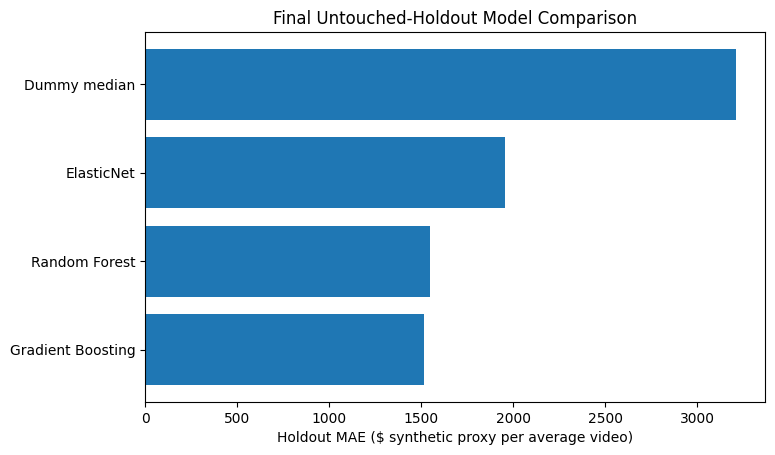

In [37]:
final_models = {
    "Dummy median": models_linear["Dummy median"],
    "ElasticNet": models_linear["ElasticNet log"],
    "Random Forest": models_tree["Random Forest log"],
    "Gradient Boosting": models_tree["Gradient Boosting log"],
}

final_rows = []
final_predictions = {}
for name, model in final_models.items():
    fitted = clone(model).fit(X_dev, y_dev)
    pred = fitted.predict(X_test)
    final_predictions[name] = pred
    final_rows.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "Median_AE": np.median(np.abs(y_test.to_numpy() - pred)),
        "RMSE": mean_squared_error(y_test, pred) ** .5,
        "R2": r2_score(y_test, pred),
    })

final_results = pd.DataFrame(final_rows).sort_values("MAE")
display(final_results)

plt.figure(figsize=(8, 4.8))
plot_df = final_results.sort_values("MAE")
plt.barh(plot_df["Model"], plot_df["MAE"])
plt.xlabel("Holdout MAE ($ synthetic proxy per average video)")
plt.title("Final Untouched-Holdout Model Comparison")
plt.show()

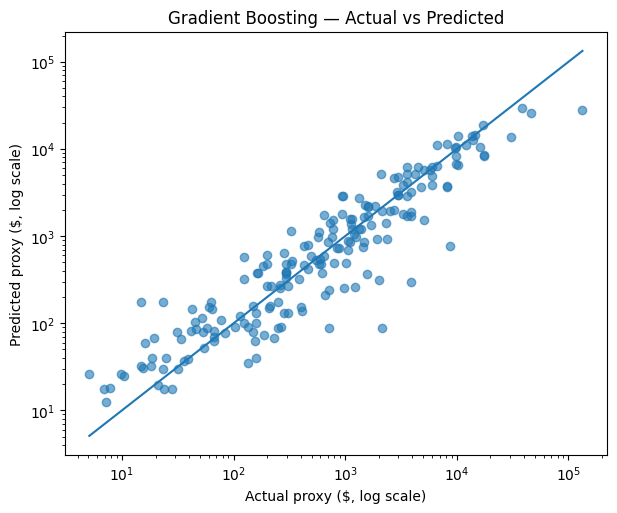

In [38]:
# Actual vs predicted for frozen primary model.
gbr_pred = np.asarray(final_predictions["Gradient Boosting"])
y_test_arr = y_test.to_numpy()

plt.figure(figsize=(7, 5.5))
plt.scatter(y_test_arr, gbr_pred, alpha=.6)
lo = max(1, min(y_test_arr.min(), gbr_pred.min()))
hi = max(y_test_arr.max(), gbr_pred.max())
plt.plot([lo, hi], [lo, hi])
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Actual proxy ($, log scale)")
plt.ylabel("Predicted proxy ($, log scale)")
plt.title("Gradient Boosting — Actual vs Predicted")
plt.show()

,n,median_target,MAE,median_AE,mean_residual
quintile,,,,,
Q1 lowest,39,30.9000,35.3410,17.6676,-33.9054
Q2,39,200.1000,121.4957,86.7894,-32.8064
Q3,39,651.6000,426.4265,305.3894,-161.0938
Q4,39,"1,845.3000",821.8407,571.5802,-55.5911
Q5 highest,39,"8,100.0000","6,161.9999","2,026.1713","5,208.8725"


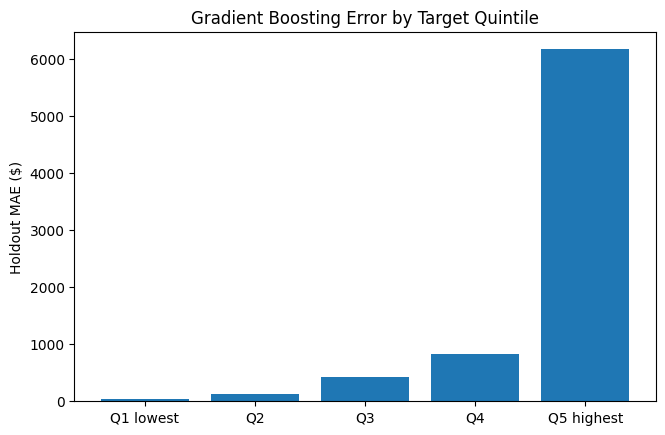

In [39]:
# Error by target quintile.
q = pd.qcut(
    y_test.rank(method="first"), q=5,
    labels=["Q1 lowest", "Q2", "Q3", "Q4", "Q5 highest"]
)
err = pd.DataFrame({
    "actual": y_test_arr,
    "pred": gbr_pred,
    "abs_error": np.abs(y_test_arr - gbr_pred),
    "residual": y_test_arr - gbr_pred,
    "quintile": q.to_numpy(),
})

q_report = err.groupby("quintile", observed=False).agg(
    n=("actual", "size"),
    median_target=("actual", "median"),
    MAE=("abs_error", "mean"),
    median_AE=("abs_error", "median"),
    mean_residual=("residual", "mean"),
)
display(q_report)

plt.figure(figsize=(7.5, 4.8))
plt.bar(q_report.index.astype(str), q_report["MAE"])
plt.ylabel("Holdout MAE ($)")
plt.title("Gradient Boosting Error by Target Quintile")
plt.show()

In [40]:
# Largest holdout errors with creator identity restored.
test_meta = df_engagement.loc[X_test.index, [
    "Channel Name", "Rank", "Subscribers", "Average Views", "Average Likes", "Average Comments", "Cluster_Name"
]].copy()
test_meta["Actual_Proxy"] = y_test
test_meta["GBR_Prediction"] = gbr_pred
test_meta["Abs_Error"] = np.abs(y_test_arr - gbr_pred)
test_meta["Residual"] = y_test_arr - gbr_pred

display(test_meta.nlargest(10, "Abs_Error"))

largest = test_meta.nlargest(1, "Abs_Error").iloc[0]
print("Largest-error creator:", largest["Channel Name"])
print("Share of all absolute holdout error:", largest["Abs_Error"] / test_meta["Abs_Error"].sum())
print("Top 5 error share:", test_meta.nlargest(5, "Abs_Error")["Abs_Error"].sum() / test_meta["Abs_Error"].sum())

,Channel Name,Rank,Subscribers,Average Views,Average Likes,Average Comments,Cluster_Name,Actual_Proxy,GBR_Prediction,Abs_Error,Residual
317,Bizarrap,325,"21,700,000.0000","44,500,000.0000","1,500,000.0000","66,000.0000",Current Engagement Leaders,"133,500.0000","28,311.7294","105,188.2706","105,188.2706"
336,_vector_,345,"21,300,000.0000","15,300,000.0000","812,100.0000","1,400.0000",Current Engagement Leaders,"45,900.0000","25,688.5809","20,211.4191","20,211.4191"
280,The Royalty Family,287,"23,200,000.0000","10,100,000.0000","258,100.0000","6,900.0000",Current Engagement Leaders,"30,300.0000","13,759.0489","16,540.9511","16,540.9511"
305,Beast Philanthropy,313,"22,000,000.0000","12,900,000.0000","888,700.0000","17,900.0000",Current Engagement Leaders,"38,700.0000","29,528.8177","9,171.1823","9,171.1823"
7,Vlad and Niki,8,"109,600,000.0000","5,800,000.0000","42,700.0000",0.0000,Mega-Audience / Under-Activated,"17,400.0000","8,376.2041","9,023.7959","9,023.7959"
634,GOLU008,653,"15,500,000.0000","5,800,000.0000","187,900.0000",369.0000,Current Engagement Leaders,"17,400.0000","8,536.5230","8,863.4770","8,863.4770"
356,Busy Fun Ltd,367,"20,700,000.0000","2,900,000.0000","9,300.0000",177.0000,Current Engagement Leaders,"8,700.0000",768.7637,"7,931.2363","7,931.2363"
668,Kajal Soni,687,"15,100,000.0000","5,400,000.0000","213,300.0000",354.0000,Current Engagement Leaders,"16,200.0000","10,467.8622","5,732.1378","5,732.1378"
545,La Granja del Borrego,563,"16,600,000.0000","2,200,000.0000","220,800.0000","1,800.0000",Current Engagement Leaders,"6,600.0000","11,246.5710","4,646.5710","-4,646.5710"
79,Maria Clara & JP,81,"39,400,000.0000","2,700,000.0000","20,900.0000",0.0000,Mega-Audience / Under-Activated,"8,100.0000","3,677.2753","4,422.7247","4,422.7247"


Largest-error creator: Bizarrap
Share of all absolute holdout error: 0.3564289861448648
Top 5 error share: 0.5426173090739882


In [41]:
# Error by creator segment discovered before regression.
cluster_error = test_meta.groupby("Cluster_Name").agg(
    n=("Actual_Proxy", "size"),
    median_target=("Actual_Proxy", "median"),
    MAE=("Abs_Error", "mean"),
    median_AE=("Abs_Error", "median"),
)
display(cluster_error)

,n,median_target,MAE,median_AE
Cluster_Name,,,,
Current Engagement Leaders,88,"2,825.1000","2,907.7652",689.2381
Lower-Activity Top-Tier,84,157.0500,220.6279,59.0360
Mega-Audience / Under-Activated,23,701.7000,900.0420,246.2853


# 13. Feature Importance & Ablation

,mean,std
feature,,
Average Likes,"2,474.1448",385.8217
Average Comments,160.8423,84.0406
Subscribers,63.7831,90.7126
Country,45.7599,23.2479
Category,15.5002,10.6722


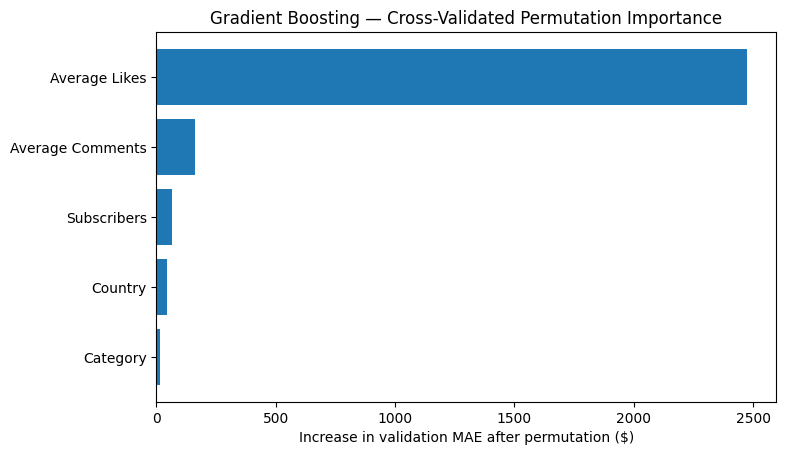

In [42]:
# Cross-validated permutation importance grouped back to original feature names.
# This evaluates predictive dependence, not causality.
def original_feature_permutation_importance(estimator, repeats=5):
    importance_rows = []
    for fold, (tr, va) in enumerate(folds, 1):
        model = clone(estimator).fit(X_dev.iloc[tr], y_dev.iloc[tr])
        baseline_pred = model.predict(X_dev.iloc[va])
        baseline_mae = mean_absolute_error(y_dev.iloc[va], baseline_pred)
        rng = np.random.default_rng(SEED + fold)
        for feature in REG_FEATURES:
            deltas = []
            for _ in range(repeats):
                Xp = X_dev.iloc[va].copy()
                Xp[feature] = rng.permutation(Xp[feature].to_numpy())
                pred = model.predict(Xp)
                deltas.append(mean_absolute_error(y_dev.iloc[va], pred) - baseline_mae)
            importance_rows.append({
                "fold": fold,
                "feature": feature,
                "delta_MAE": np.mean(deltas),
            })
    return pd.DataFrame(importance_rows)

perm = original_feature_permutation_importance(models_tree["Gradient Boosting log"])
perm_summary = perm.groupby("feature")["delta_MAE"].agg(["mean", "std"]).sort_values("mean", ascending=False)
display(perm_summary)

plt.figure(figsize=(8, 4.8))
plot_imp = perm_summary.sort_values("mean")
plt.barh(plot_imp.index, plot_imp["mean"])
plt.xlabel("Increase in validation MAE after permutation ($)")
plt.title("Gradient Boosting — Cross-Validated Permutation Importance")
plt.show()

In [43]:
# Development-CV feature ablation; do NOT use holdout to choose features.
def make_gbr_for_features(feature_list):
    num = [f for f in ["Subscribers", "Average Likes", "Average Comments"] if f in feature_list]
    cat = [f for f in ["Category", "Country", "Content Type"] if f in feature_list]
    transformers = []
    if num:
        transformers.append(("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ]), num))
    if cat:
        transformers.append(("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
            ("onehot", make_onehot()),
        ]), cat))
    prep = ColumnTransformer(transformers, sparse_threshold=0)
    reg = Pipeline([
        ("prep", prep),
        ("model", GradientBoostingRegressor(
            n_estimators=200, learning_rate=.03, max_depth=3,
            min_samples_leaf=5, random_state=SEED
        ))
    ])
    return TransformedTargetRegressor(regressor=reg, func=np.log1p, inverse_func=np.expm1)

# Use development data aligned to df_engagement indices and permit Content Type in ablation.
X_all_for_ablation = df_engagement.loc[X_dev.index, [
    "Subscribers", "Average Likes", "Average Comments", "Category", "Country", "Content Type"
]].copy()
y_ablation = y_dev.copy()

ablation_specs = {
    "Core": ["Subscribers", "Average Likes", "Average Comments", "Category", "Country"],
    "+ Content Type": ["Subscribers", "Average Likes", "Average Comments", "Category", "Country", "Content Type"],
    "- Likes": ["Subscribers", "Average Comments", "Category", "Country"],
    "- Comments": ["Subscribers", "Average Likes", "Category", "Country"],
    "- Subscribers": ["Average Likes", "Average Comments", "Category", "Country"],
    "- Category": ["Subscribers", "Average Likes", "Average Comments", "Country"],
    "- Country": ["Subscribers", "Average Likes", "Average Comments", "Category"],
    "Numeric only": ["Subscribers", "Average Likes", "Average Comments"],
}

ablation_rows = []
for name, feats in ablation_specs.items():
    model = make_gbr_for_features(feats)
    fold_maes = []
    for tr, va in folds:
        model_i = clone(model)
        model_i.fit(X_all_for_ablation.iloc[tr][feats], y_ablation.iloc[tr])
        pred = model_i.predict(X_all_for_ablation.iloc[va][feats])
        fold_maes.append(mean_absolute_error(y_ablation.iloc[va], pred))
    ablation_rows.append({"specification": name, "CV_MAE": np.mean(fold_maes)})

ablation = pd.DataFrame(ablation_rows).sort_values("CV_MAE")
core_mae = ablation.loc[ablation["specification"] == "Core", "CV_MAE"].iloc[0]
ablation["pct_change_vs_core"] = (ablation["CV_MAE"] / core_mae - 1) * 100
display(ablation)

,specification,CV_MAE,pct_change_vs_core
3,- Comments,"1,501.4204",-1.3453
1,+ Content Type,"1,510.5493",-0.7455
0,Core,"1,521.8947",0.0000
5,- Category,"1,537.6142",1.0329
6,- Country,"1,541.0688",1.2599
7,Numeric only,"1,544.0395",1.4551
4,- Subscribers,"1,568.1079",3.0366
2,- Likes,"2,101.7799",38.1028


# 14. Final CRISP-DM Findings

## Executive findings

1. **The raw file is not analysis-ready.** It contains a blank row, appended exact duplicates, repeated channel entities, string-encoded magnitudes, heavy categorical missingness, and a structured 0/0/0 engagement pattern.
2. **Top-creator metrics are multiplicative and extremely right-skewed.** Logarithmic representations are much more appropriate for modeling and clustering than raw-scale Euclidean treatment.
3. **Subscriber scale and current engagement are different latent dimensions.** Subscribers are almost perfectly tied to Rank but only weakly associated with current engagement within this already-elite population.
4. **Views, Likes, and Comments form a strong engagement system**, with Likes the strongest independently observed proxy for the view-derived regression target.
5. **Three useful creator personas emerge:** Lower-Activity Top-Tier, Current Engagement Leaders, and Mega-Audience / Under-Activated.
6. **Outliers should not be mechanically deleted.** Legitimate superstar channels are central to the population. The suspicious observations are the structured zero-engagement records, not the largest creators.
7. **The CSV cannot support true income prediction.** There is no observed revenue/income target.
8. **A perfect Views→proxy regression is invalid target leakage.** The strong supervised exercise is the leakage-restricted experiment.
9. **Log-target Random Forest and Gradient Boosting outperform the median baseline strongly on MAE**, while the extreme superstar tail remains the dominant failure mode.
10. **Content Type is not recommended for the core model** because its severe missingness and overlap with Category do not yield consistent incremental value.

## Final model recommendation

For the **synthetic fixed-RPM proxy teaching problem**, use the frozen **log-target Gradient Boosting** pipeline as the primary MAE-oriented model, with Random Forest as an effectively tied challenger and ElasticNet as an interpretable extrapolating benchmark.

Do **not** describe this as a model of actual creator income.

For a real production revenue model, collect independently observed creator-side revenue by time period, viewer geography, monetized views/RPM, upload cadence, content format, watch time, and other revenue sources. Use **temporal validation** rather than random cross-sectional splitting.

# 15. Deployment-Readiness Assessment

### Creator segmentation

**Prototype-ready** for descriptive analytics and dashboarding, provided cluster assignments are treated as behavioral summaries rather than immutable natural classes.

### Actual creator-income prediction

**Not deployment-ready.** The limiting factor is missing target data, not algorithm sophistication.

A production design should monitor:

- MAE / RMSE / $R^2$
- error by revenue quantile
- top-decile / top-5% creator error
- out-of-domain predictor values
- missingness / category drift
- feature distribution drift
- temporal performance decay
- retraining triggers

# 16. Reproducibility Checklist

- [x] Immutable raw input retained
- [x] Unit of analysis defined as one creator/channel
- [x] Structural duplicate rules documented
- [x] Compact numeric parser validated with zero parse failures
- [x] Sentinel-zero rule documented
- [x] Fixed random seed
- [x] Feature definitions explicit
- [x] Leakage register explicit
- [x] Preprocessing inside sklearn pipelines
- [x] Baseline models retained
- [x] Same development folds used for paired comparisons
- [x] Final holdout isolated until model selection
- [x] MAE, RMSE, and $R^2$ all reported
- [x] Tail / superstar sensitivity analyzed
- [x] Feature ablation conducted on development data

---

## End of notebook

This notebook intentionally prioritizes **scientific validity, traceability, and interpretability** over producing a deceptively impressive metric. That is the central CRISP-DM lesson of the case study.